# Taller NoSQL 

Diseñado por: Maria Alejandra Angulo Mejia

En este cuaderno vamos a trabajar con bases de datos No SQL, revisaremos como se pueden manipular bases de datos documentales como lo es MongoDB desde Python, asi como la forma de generar visualizaciones que permitan entender mejor la base de datos.

Se tiene como prerequisito el desarrollo del taller 2 del curso.

La estructura de este cuaderno es la siguiente:

1) [Conexión a la base de datos](#conexion-a-la-base-de-datos)
    - Configurar el ambiente
2) [Operaciones CRUD y Consultas](#crud-y-consultas-en-pymongo)
    - Básicos de pymongo
    - Explicación de consultas (MongoDB Compass y pymongo)
    - Ejercicios CRUD
    - Ejercicios Consultas

Para conectar la base de datos de MongoDB se utilizará la librería [pymongo](https://pymongo.readthedocs.io/en/stable/tutorial.html). Para visualización de los datos se utilizara la la libreria de [Pandas](https://pandas.pydata.org/) y para la visualización  de los datos se usará [Seaborn](https://seaborn.pydata.org/) y [Matplotlib](https://matplotlib.org/).

En este cuaderno para el nombramiento de variables se utilizará la convención *snake_case*, esto para generar uniformidad en el código. Asimismo, procure que los nombres de sus variables sean indicativos para mejorar la legibilidad de su código.


# Conexion a la base de datos

## Configurar el ambiente

Esta configuración del ambiente supone que tiene instaladas las librerías pandas, seaborn y matplotlib; librerías instaladas durante el taller 2. En caso de no tener estas librerías, revise el taller 2 y realice la instalación.

Para realizar una conexión exitosa a la base de datos se requiere instalar ciertas dependencias en su máquina. Se puede hacer desde una terminal, corriendo el comando:

```bash
pip install pymongo
```

O corriendo la siguiente celda. Este paso solo debe realizarse una **única** vez. Una vez instaladas las dependencias no es necesario repetir el proceso.



In [ ]:
#Instalar librería pymongo
!pip install pymongo

Para familiarse más con la librería responda las siguientes preguntas.

¿Cómo funciona la librería pymongo?

¿Como se parece y se diferencia de oracledb?

Ya con el ambiente configurado se cargan las librerías necesarias para la ejecución apropiada de este cuaderno.

In [ ]:
#Importar librerías

#Pymongo
import pymongo
#Importar MongoClient para conectarse a la base de datos
from pymongo import MongoClient

#Pandas
import pandas as pd

#Seaborn
import seaborn as sns

#Matplotlib
import matplotlib.pyplot as plt


## Asociar credenciales para establecer la conexión a la base de datos MongoDB

Este cuaderno utiliza la base de datos NoSQL de Parranderos, por lo cual, como siguiente paso, debe ingresar las credenciales de MongoDB que le fueron compartidas.

In [ ]:
#Ingrese la URL de conexión a su base de datos MongoDB. MongoClient es la clase que nos permite establer la conexion a la base de datos.
cliente = MongoClient('mongodb://localhost:27017/')

#Conectar a la base de datos y sus colecciones. Debe cambiar 'parranderos' por el nombre exacto de su base de datos.
db = cliente['parranderos']

#Traer a memoria principal la información de las colecciones. Cambie el nombre por el nombre exacto de las colecciones que tiene en su base de datos (Ej Bares en vez de bares).
coleccion_bares = db['bares']
coleccion_bebedores = db['bebedores']

Realice una consulta para validar que está conectado a la base de datos y que tiene acceso a una colección. En este ejemplo, se van a traer los primeros 6 documentos relacionados con la colección de bares. Por esta razón, deben aparecer los 6 primeros bares del documento bares.

In [ ]:
#Extraer datos de la colección bares
cursor = coleccion_bares.find().limit(6)
# Convertir a DataFrame
df_grado_alcohol = pd.DataFrame(list(cursor))

# Mostrar
df_grado_alcohol

,_id,cant_sedes,ciudad,nombre,presupuesto,oferta_bebidas
0,58,7,Medellin,Bares Colombia,Bajo,NaN
1,59,5,Medellin,bar medellin,Bajo,NaN
2,60,5,Santa Marta,bar santa Marta,Bajo,"[{'nombre': 'cavernet', 'tipo': 'vino tinto', ..."
3,61,3,Santa Marta,bar santa Marta,Bajo,NaN
4,62,1,Bogotá,El Rincón Cubano,Alto,NaN
5,10,1,Barranquilla,Casa De La Cerveza,Bajo,"[{'nombre': 'cavernet', 'tipo': 'vino tinto', ..."


# CRUD y consultas en pymongo

Pymongo, al igual que oracledb en el taller pasado, es una librería que permite acceder y manipular directamente la base de datos desde Python.

**CRUD**

Las funciones brindadas por la librería tienen nombres similares a las que tiene MongoDB. A continuación, se mostrará cada una de las acciones CRUD con el siguiente ejemplo, el cual está basado en parranderos.

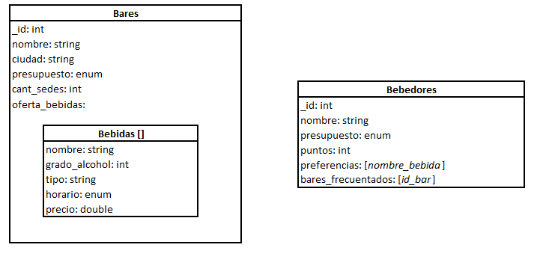

La instancia de la colección de la base de datos de este modelo se llama coleccion_bares.

*CREATE*

Para crear el documento se inserta todo el JSON en un diccionario, en el mismo formato que se haría en MongoDB y se inserta a través de la función insert_one().

```python
bar = {
    "_id": 1,
    "nombre": "Bar El Cielo",
    "ciudad": "Bogotá",
    "presupuesto": "alto",
    "cant_sedes": 3,
    "oferta_bebidas": [
        {
            "nombre": "Club Colombia",
            "grado_alcohol": 4,
            "tipo": "cerveza",
            "horario": "nocturno",
            "precio": 8000.0
        },
        {
            "nombre": "Aguardiente Antioqueño",
            "grado_alcohol": 29,
            "tipo": "aguardiente",
            "horario": "todo_el_dia",
            "precio": 12000.0
        }
    ]
}
coleccion_bares.insert_one(bar)
```

*READ*

En el caso de leer un documento, se debe saber que se desea. A continuación se muestra un ejemplo para traer información de todos los bares, y otro para filtrar por campos específicos. Esto se hace normalmente con las funciones find(), si se busca más de un documento, o find_one() si solo se quiere obtener un único resultado.

- Para leer todos los bares:

```python
for bar in coleccion_bares.find():
    print(bar)
```

- Para buscar un bar por su id:

```python
bar = coleccion_bares.find_one({ "_id": 1 })
print(bar)
```

- Para buscar bares donde se ofrezca una bebida con un nombre específico:

```python
for bar in coleccion_bares.find({ "oferta_bebidas.nombre": "Club Colombia" }):
    print(bar)
```

*UPDATE*

Para generar una actualización de un documento específico se necesita saber si se quiere modificar sobre un documento ya existente o reemplazar el documento, ya que la función a utilizar cambia según lo deseado. En caso de querer modificar un documento se utiliza update_one(). En caso de querer reemplazar por completo el documento se debe usar replace_one().

- Agregar una bebida a la oferta, actualizando un documento:

```python
coleccion_bares.update_one(
    { "_id": 1 },
    { "$push": { "oferta_bebidas": {
        "nombre": "Ron Medellín",
        "grado_alcohol": 5,
        "tipo": "ron",
        "horario": "nocturno",
        "precio": 15000.0
    }}}
)
```

- Cambiar el número de sedes de un bar, actualizando un documento:

```python
coleccion_bares.update_one(
    { "_id": 1 },
    { "$set": { "cant_sedes": 5 } }
)
```

- Reemplazar completamente un documento:

```python
nuevo_bar = {
    "_id": 1,
    "nombre": "Bar El Cielo Renovado",
    "ciudad": "Medellín",
    "presupuesto": "medio",
    "cant_sedes": 1,
    "oferta_bebidas": [
        {
            "nombre": "Poker",
            "grado_alcohol": 4,
            "tipo": "cerveza",
            "horario": "todo_el_dia",
            "precio": 6000.0
        }
    ]
}

coleccion_bares.replace_one(
    { "_id": 1 },
    nuevo_bar
)
```
La función replace_one() elimina todos los campos previos y deja los que estén en nuevo_bar.

*DELETE*

Para eliminar un documento por completo se utiliza la función delete_one(), mientras que en caso de querer eliminar una instancia de un objeto embebido se debe utilizar update_one() y la acción de pull.

Eliminar un curso completo:

```python
coleccion_bares.delete_one({ "_id": 1 })
```

Eliminar una bebida de la oferta de un bar:
```python
collection.update_one(
    { "codigo": "BDN101" },
    { "$pull": { "estudiantes": { "codigo": "E001" } } }
)
```


**Consultas**

Para realizar consultas simples, puede definir la consulta en una variable e ingresar la variable como parámetro de la función find(). Después de obtener esta información se convierte a un DataFrame para poder visualizarlo en el cuaderno.

Ejemplo:

```python
filtro = {
    "ciudad": "Bogotá",
    "presupuesto": "alto",
    "oferta_bebidas.tipo": "cerveza"
}
# Ejecutar consulta
cursor = coleccion_bares.find(filtro)

# Convertir a DataFrame
df = pd.DataFrame(list(cursor))
```

En caso de las consultas avanzadas, donde la mayoría se construyen a través de pipelines en MongoDB Compass, lo que se hace es crear una variable donde se copia el texto que produce MongoDB. Luego esa variable se pasa como parámetro en la función aggregate().

Un pipeline es una secuencia de etapas que se aplican una tras otra sobre los documentos de una colección. Cada etapa transforma o filtra los datos y pasa el resultado a la siguiente. Las etapas más comunes son:

- **$match**: filtra documentos según una condición, similar al find().
- **$group**: agrupa documentos por un campo y permite calcular acumulados como sumas o promedios.
- **$project**: selecciona o excluye campos del documento resultado.
- **$sort**: ordena los resultados por uno o más campos.
- **$unwind**: descompone un array embebido en documentos individuales, uno por cada elemento del array.


Ejemplo:

```python
pipeline = [
    {
        "$group": {
            "_id": "$ciudad",
            "totalBares": { "$sum": 1 }
        }
    }
]
# Guardar documentos filtrados
resultado = coleccion_bares.aggregate(pipeline)
# Convertir a DataFrame
df = pd.DataFrame(list(resultado))
df
```

Al igual que en el taller 2 se utilizan los Data Frames para visualizar las consultas y más adelante poder realizar visualizaciones. Es importante anotar que para que pueda ejecutarse el DataFrame, hay que convertir el resultado en lista, que es uno de los formatos que recibe Pandas.

# Ejercicios de MongoDB

**Contexto**

Los ingenieros encargados de diseñar la base de datos de Parranderos deciden que quieren usar una base de datos documental en MongoDB para hacer las consultas más veloces. El punto de partida fue el diagrama relacional original.

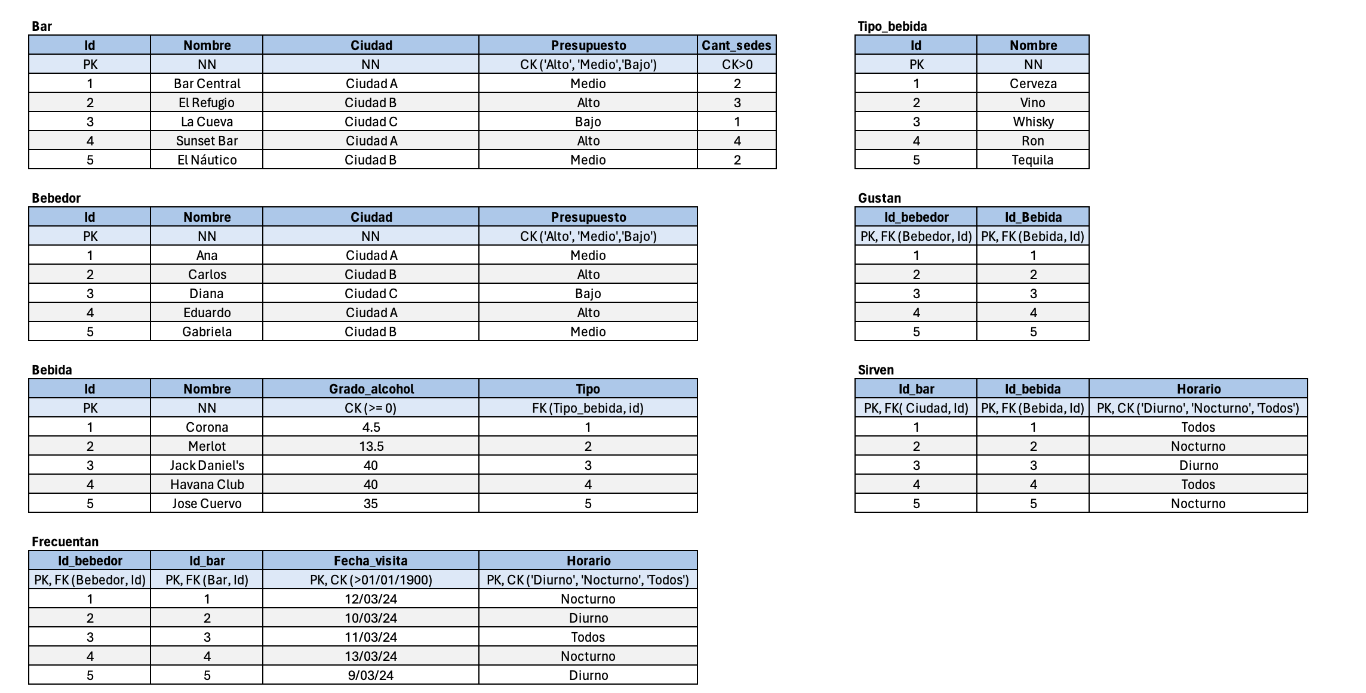

A partir del contexto dado, responda las siguientes preguntas

### Modelado de datos (20%)

Los ingenieros a cargo del proyecto decidieron transformar los esquemas de Parranderos de acuerdo con la figura a continuación

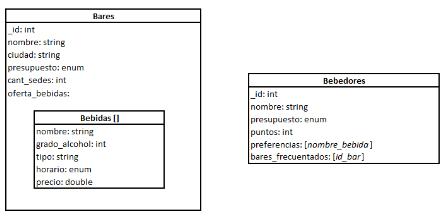

1) (10%) ¿Qué estrategia se utilizó para modelar cada entidad de Parranderos dentro de la base de
datos documental? ¿Cuáles relaciones se modelaron como objetos embebidos y cuáles se modelaron
como referencias? ¿Qué relaciones y entidades del modelo se simplificaron?¿Ventajas y desventajas de estas decisiones?

<span style="color:green">Respuesta</span>

En primera instancia, la entidad de Bebidas desapareció como una entidad independiente y se embebió dentro de bares. Sólo se consideran las entidades Bares y Bebedores como colecciones. En particular Bebedores hora referencia a las bebidas que prefiere a través del nombre de las bebidas, y tiene los ids de los bares frecuentados. Adicionalmente las Bebidas ya no tienen un TipoBebida como una entidad, sino como un tipo String.

2) (10%) ¿Cuáles son los tipos de consultas que podrían justificar las decisiones de modelado de
Parranderos No relacional? ¿Qué tipos de requerimientos de consulta se ven priorizados por el modelo?¿Qué tipo de requerimiento pierden prioridad? Mencione algunos ejemplos de requerimiento de consultas para justificar su respuesta.

<span style="color:green">Respuesta</span>

Este modelo tiene preferencia sobre consultas a los bares y a su oferta de bebidas y sobre los bebedores; y hace más difícil realizar consultas sobre las bebidas en general. Si tenemos una gran cantidad de Bares y un alto número de Bebedores, este diseño toma en cuenta también las carga de trabajo, al tiempo que asume que habrán pocas bebidas en total y que éstas podrán replicarse sin mayor dificultad. Algunas consultas que podrían hacerse fácilmente:
 - Para un bar, consulta su oferta de bebidas.
 - Consultas los bares por ciudad.
 - Consultar los bares con mayor oferta de bebidas.
 - Consultas los bares por presupuesto.
 - Consultar los bebedores que frecuentan más bares.
 - Consultas los nombres de los bares frecuentados por bebedores.

### CRUD Básico (30%)

Como parte del diseño del nuevo Parranderos se propuso incluir una clase Direccion para ampliar los datos de las ubicaciones asociadas a los distintos bares. Este es el nuevo diagrama de clases que afecta la clase Bar de Parranderos original.

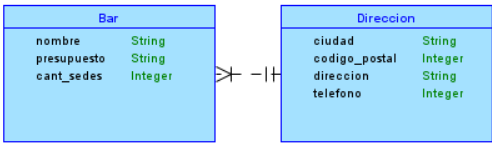

3) (8%) Realice las modificaciones necesarias al esquema existente de parranderos para reflejar este cambio. A la luz de la filosofía de modelado de datos para MongoDB, justifique su decisión.

<span style="color:green">Respuesta</span>

Usando la frase "Lo que se consulta conjuntamente, se almacena conjuntamente", la mejor decisión será embeber el objeto dirección dentro de los documentos de Bares:

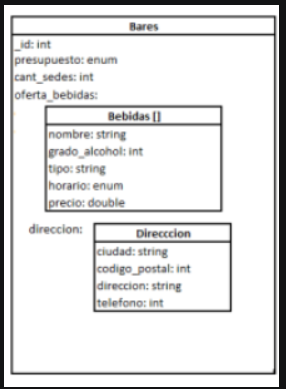

Dado que la mayoría de consultas que se hacen sobre direcciones siempre están relacionadas con un bar, esto es, a partir de un bar se requiere obtener sus direcciones y no lo contrario.

4) (8%) Construya los esquemas de validación de los esquemas de la base de Parranderos que se ven
afectados con este cambio.

<span style="color:green">Respuesta</span>

{ $jsonSchema: {

    bsonType: 'object',

    required: [

        'nombre',

        'presupuesto',

        'cant_sedes',

        'direccion'

        ],

        properties: {

            nombre: {

                bsonType: 'string'

                }, presupuesto: {

                    'enum': [ 'Alto', 'Medio', 'Bajo' ] },

                    cant_sedes: { bsonType: 'int' },

                    direccion: { bsonType: 'object', required: [ 'ciudad' ], properties: { ciudad:
                     { bsonType: 'string' },

                    codigo_postal: { bsonType: 'double' },

                    direccion: { bsonType: 'string' }, telefono: { bsonType: 'double' } } },

                    bebidas: { bsonType: 'array', items: { bsonType: 'object', required:
                    [
                    'nombre', 'tipo', 'horario', 'precio' ], properties: { nombre: { bsonType:
                    'string' },

                    tipo: { bsonType: 'string' }, horario: { 'enum': [ 'diurno', 'nocturno', 'todos' ] },

                    precio: { bsonType: 'int' }

                    }

                }

            }

        }

    }

}



5) (4%) Agregue a la base de datos al menos 20 nuevos bares que reflejen las modificaciones.

<span style="color:green">Respuesta</span>

Ejemplo con 1 db.bares.insertMany([{

    "_id:101,
    
    "nombre": "bar de prueba",
    
    "presupuesto": "Bajo",
    
    "cant_sedes": 10,
    
    "direccion": { "ciudad": "Cali", "codigo_postal": 12345, "direccion": "Calle 12-43", "telefono": 12345678 } }], …)

6) (10%) Realice la actualización de todos los documentos de Mongo que no tengan dirección de acuerdo
con la siguiente lista:

    - Ciudad: La ciudad original en donde está ubicada el bar.

    - Código postal: Un número aleatorio de 5 dígitos entre 10000 y 99999.

    - Direccion: Calle <r1> con carrera <r2>. Reemplace <r1> y <r2> por dos números aleatorios entre 1 y 150.

    - Teléfono: Un número de 7 dígitos aleatorio con el indicativo correspondiente a cada ciudad

    (AYUDA: revise la documentación de la función [$RAND](https://www.mongodb.com/docs/manual/reference/operator/aggregation/rand/)).

<span style="color:green"><strong>-- Solución con `$out` (debe correrse antes del punto 3, o elimina los 20 documentos)</strong></span>

```javascript
db.bares.aggregate([
  {
    $match: {
      direccion: { $eq: null }  // Filtra documentos que no tienen dirección
    }
  },
  {
    $addFields: {
      'direccion.ciudad': '$ciudad',
      'direccion.codigo_postal': {
        $round: [
          { $sum: [ { $multiply: [ { $rand: {} }, 89999 ] }, 10000 ] }
        ]
      },
      'direccion.telefono': {
        $round: [
          { $sum: [ { $multiply: [ { $rand: {} }, 8999999 ] }, 1000000 ] }
        ]
      },
      'direccion.direccion': {
        $concat: [
          "Calle ",
          { $toString: { $round: [ { $sum: [ { $multiply: [ { $rand: {} }, 149 ] }, 1 ] } ] } },
          " con carrera ",
          { $toString: { $round: [ { $sum: [ { $multiply: [ { $rand: {} }, 149 ] }, 1 ] } ] } }
        ]
      }
    }
  },
  {
    $out: "bares"
  }
])

```

<span style="color:green"><strong>-- Solución con `$merge`</strong></span>

```javascript
db.bares.aggregate([
  {
    $match: {
      direccion: { $eq: null }  // Filtra documentos sin dirección
    }
  },
  {
    $addFields: {
      'direccion.ciudad': '$ciudad',
      'direccion.codigo_postal': {
        $round: [
          { $sum: [ { $multiply: [ { $rand: {} }, 89999 ] }, 10000 ] }
        ]
      },
      'direccion.telefono': {
        $round: [
          { $sum: [ { $multiply: [ { $rand: {} }, 8999999 ] }, 1000000 ] }
        ]
      },
      'direccion.direccion': {
        $concat: [
          "Calle ",
          { $toString: { $round: [ { $sum: [ { $multiply: [ { $rand: {} }, 149 ] }, 1 ] } ] } },
          " con carrera ",
          { $toString: { $round: [ { $sum: [ { $multiply: [ { $rand: {} }, 149 ] }, 1 ] } ] } }
        ]
      }
    }
  },
  {
    $merge: {
      into: "bares",
      whenMatched: "merge",
      whenNotMatched: "insert"
    }
  }
])

```

### Consultas en bases de datos documentales (30%)

Asobares Colombia quiere empezar la implementación de la nueva app de Parranderos. Para esto le ha encargado diseñar dos consultas para la nueva base documental en MongoDB. Resuelva cada una de las siguientes consultas e incluya en su informe el script para cada consulta:

7) (4%) Se quieren conocer todos los bares que se encuentren en el mismo código postal que entre como parámetro.

In [ ]:
param = 11001
resultado = coleccion_bares.find({'direccion.codigo_postal': param})
# Convertir a DataFrame
df_bares_codigo_postal = pd.DataFrame(list(resultado))
# Mostrar
df_bares_codigo_postal


8) (10%)  Se quieren conocer los nombres de bebedores que frecuentan entre 10 y 20 bares, junto con los ids de los bares que frecuentan.

In [ ]:
consulta = {
    "$and": [
        {"bares_frecuentados": {"$ne": None}},
        {"$expr": {"$gte": [{"$size": "$bares_frecuentados"}, 10]}},
        {"$expr": {"$lte": [{"$size": "$bares_frecuentados"}, 20]}}
    ]
}

proyeccion = {
    "_id": 0,
    "nombre": 1,
    "bares_frecuentados": 1
}

resultados = coleccion_bebedores.find(consulta, proyeccion)

# Si quieres convertirlo en DataFrame:
import pandas as pd
df = pd.DataFrame(list(resultados))
df

,nombre,bares_frecuentados
0,Angelica Beltran,"[15, 3, 8, 30, 55, 11, 50, 4, 41, 32, 40]"
1,Patricia Benitez,"[44, 43, 14, 27, 32, 19, 42, 16, 51, 12]"
2,Juliette Dominguez,"[13, 48, 49, 20, 55, 2, 35, 9, 52, 28]"
3,Pedro Garcia,"[32, 42, 43, 17, 13, 27, 24, 48, 41, 6]"
4,Martin Romero,"[25, 52, 40, 16, 1, 53, 30, 24, 36, 54, 31]"
5,Florencia Garcia,"[43, 10, 20, 39, 16, 40, 53, 48, 37, 47]"
6,Laura Williams,"[15, 16, 37, 50, 54, 34, 28, 27, 8, 45]"
7,Benjamin Ubeda,"[45, 52, 23, 28, 30, 55, 43, 1, 14, 47, 33]"
8,Florencia Arias,"[4, 32, 14, 41, 24, 7, 31, 16, 18, 8]"
9,Joaquin Arias,"[24, 28, 50, 39, 32, 3, 56, 27, 30, 19]"


9) (16%) Se quiere conocer para cada ciudad cuál es el tipo de bar más común que hay según su
presupuesto (Ej: esta consulta debería indicar que para Bogotá hay bares de presupuesto bajo).

In [ ]:
pipeline = [
    {"$match": {"ciudad": {"$ne": None}}},
    {"$group": {
        "_id": {"ciudad": "$ciudad", "presupuesto": "$presupuesto"},
        "conteo": {"$sum": 1}
    }},
    {"$sort": {"_id.ciudad": 1, "conteo": -1}},
    {"$group": {
        "_id": "$_id.ciudad",
        "presupuesto": {"$first": "$_id.presupuesto"}
    }}
]

resultados = list(coleccion_bares.aggregate(pipeline))

import pandas as pd
df = pd.DataFrame(resultados)
df.columns = ["ciudad", "presupuesto_mas_comun"]
df

,ciudad,presupuesto_mas_comun
0,Bogotá,Alto
1,Barranquilla,Bajo
2,Medellin,Alto
3,Cartagena,Bajo
4,Cali,Bajo
5,Bogota,Bajo
6,Santa Marta,Alto
